In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import time
import sys
from scipy import stats

In [96]:
n_samp = 10000

# 1. Експоненційний
def generator_1(n):
    u = np.random.uniform(0, 1, n)
    return -2 * np.log(u)

# 2. Рівномірний
def generator_2(n):
    a = 2521490391
    c = 11
    m = 2**48
    X = (m - 1) // 2

    results = [float(X) / (m - 1)]

    for _ in range(n - 1):
        X = (a * X + c) % m
        results.append(float(X) / (m - 1))

    return np.array(results)

# 3. Нормальний
def generator_3(n):
    sigma = 0.1
    a = 0.5
    k = 12
    m = 6

    u = np.random.uniform(0, 1, (n, k))
    mu = np.sum(u, axis=1) - m
    return sigma * mu + a

# 4. Ерланга
def generator_4(n):
    k = 4
    u = np.random.uniform(0, 1, (n, k))
    return -3 * np.sum(np.log(u), axis=1)

# 5. Пуассона
def generator_5(n):
    L = math.exp(-3)
    results = []

    for _ in range(n):
        k = 0
        p = 1.0
        while True:
            k += 1
            p *= random.random()
            if p <= L:
                break
        results.append(k - 1)
    return np.array(results)

In [97]:
%time
sequences = {
    "Rule 1": generator_1(n_samp),
    "Rule 2": generator_2(n_samp),
    "Rule 3": generator_3(n_samp),
    "Rule 4": generator_4(n_samp),
    "Rule 5": generator_5(n_samp)
}

CPU times: user 4 μs, sys: 0 ns, total: 4 μs
Wall time: 10.7 μs


In [98]:
def analyze_sequence(name, data):
    print(f"{name}:")
    mean = np.mean(data)
    var = np.var(data)
    std = np.std(data)
    print(f"Mean: {mean:.4f}")
    print(f"Variance: {var:.4f}")
    print(f"Std Dev: {std:.4f}")

    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=30, edgecolor='black')
    plt.title(f"Histogram for {name}")
    plt.grid(True, alpha=0.3)
    plt.show()

Rule 1:
Mean: 2.0065
Variance: 3.9471
Std Dev: 1.9867


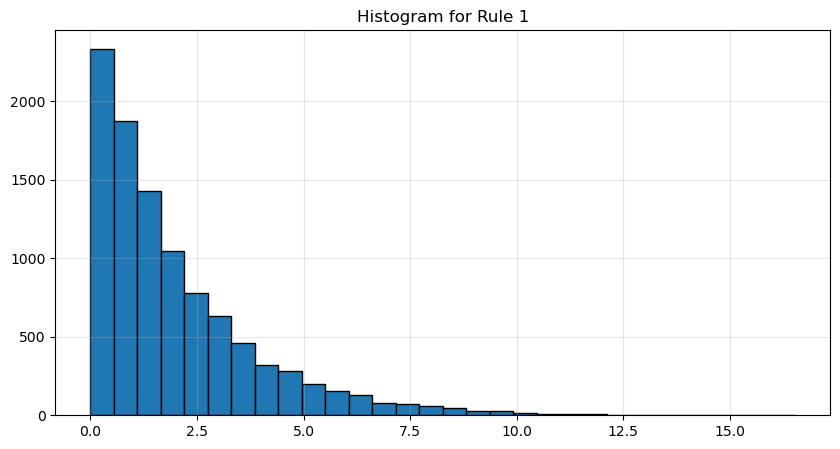

Rule 2:
Mean: 0.4994
Variance: 0.0840
Std Dev: 0.2898


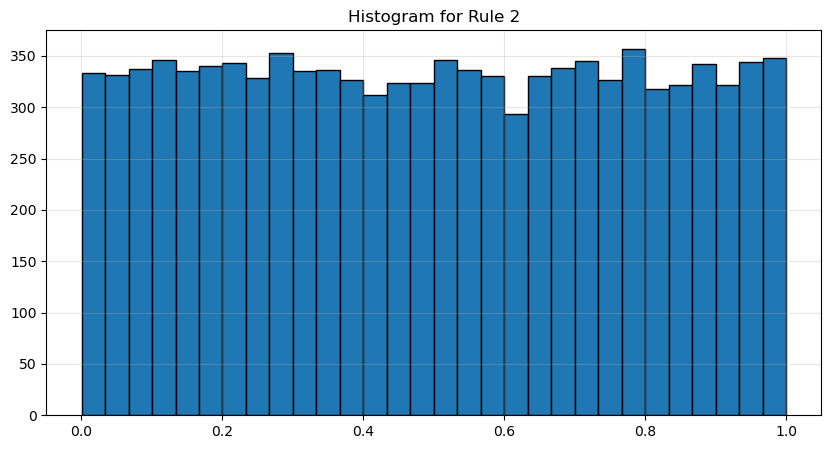

Rule 3:
Mean: 0.4999
Variance: 0.0100
Std Dev: 0.0999


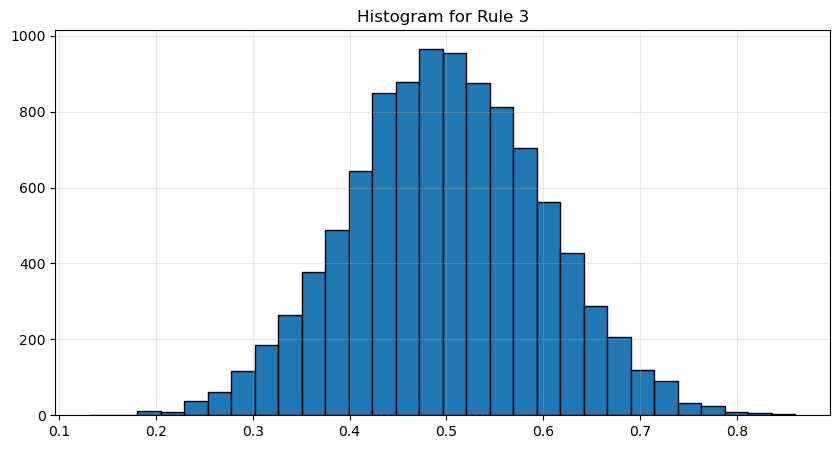

Rule 4:
Mean: 12.0161
Variance: 35.9452
Std Dev: 5.9954


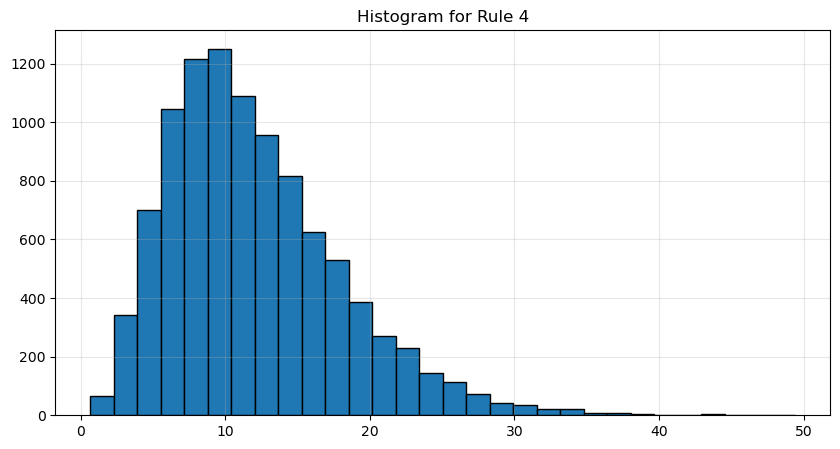

Rule 5:
Mean: 3.0175
Variance: 2.9450
Std Dev: 1.7161


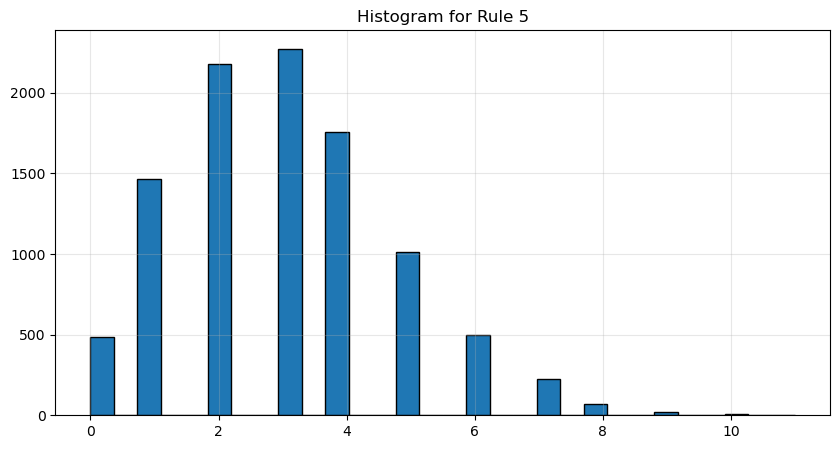

In [99]:
for name, seq in sequences.items():
    analyze_sequence(name, seq)

In [100]:
def chi_squared_test(data, distribution, **params):
    k = 20
    n = len(data)
    y, x = np.histogram(data, bins=k)

    expected = []
    for i in range(k):
        prob = distribution.cdf(x[i+1], **params) - distribution.cdf(x[i], **params)
        expected.append(prob * n)

    expected = np.array(expected)
    observed = np.array(y)

    expected = expected * (np.sum(observed) / np.sum(expected))
    num_params = len(params)
    chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected, ddof=num_params)

    return p_value

def check_poisson(data, lam):

    n = len(data)
    max_k = int(np.max(data))
    observed = np.bincount(data.astype(int), minlength=max_k+1)

    k_values = np.arange(len(observed))
    expected_probs = stats.poisson.pmf(k_values, mu=lam)
    expected_probs[-1] += 1 - np.sum(expected_probs)
    expected = expected_probs * n

    obs_filtered = observed[expected > 0]
    exp_filtered = expected[expected > 0]

    exp_filtered = exp_filtered * (np.sum(obs_filtered) / np.sum(exp_filtered))
    chi2_stat, p_value = stats.chisquare(f_obs=obs_filtered, f_exp=exp_filtered, ddof=1)

    return p_value

In [101]:
print("\nЕкспоненційний закон:")
lambdas = [0.1, 0.2, 0.33, 0.5, 0.66, 0.8]
for l in lambdas:
    p = chi_squared_test(sequences['Rule 1'], stats.expon, scale=1/l)
    print(f"  Lambda={l:4}: p-value = {p:.5f} {'[Так]' if p > 0.05 else ''}")

print("\nРівномірний закон:")
p = chi_squared_test(sequences["Rule 2"], stats.uniform, loc=0, scale=1)
print(f"  Uniform [0,1]: p-value = {p:.5f} {'[Так]' if p > 0.05 else ''}")

print("\nНормальний закон:")
mus = [0.4, 0.45, 0.5, 0.6]
sigmas = [0.08, 0.1, 0.12]
for m in mus:
    for s in sigmas:
        p = chi_squared_test(sequences["Rule 3"], stats.norm, loc=m, scale=s)
        if p > 0.0001:
            print(f"  Mu={m}, Sigma={s}: p-value = {p:.5f} {'[Так]' if p > 0.05 else ''}")

print("\nРозподіл Ерланга:")
ks = [2.5, 3, 3.5, 4, 4.5, 5]
lambdas_erl = [0.3, 0.333, 0.35, 0.4]

for k in ks:
    for l in lambdas_erl:
        p = chi_squared_test(sequences["Rule 4"], stats.gamma, a=k, scale=1/l)
        if p > 0.0001:
            print(f"  k={k}, lambda={l:.3f}: p-value = {p:.5f} {'[Так]' if p > 0.05 else ''}")

print("\nРозподіл Пуассона:")
lambdas_pois = [2.8, 2.9, 3.0, 3.02, 3.1, 3.2]
for l in lambdas_pois:
    p = check_poisson(sequences["Rule 5"], l)
    print(f"  Lambda={l}: p-value = {p:.5f} {'[Так]' if p > 0.05 else ''}")


Експоненційний закон:
  Lambda= 0.1: p-value = 0.00000 
  Lambda= 0.2: p-value = 0.00000 
  Lambda=0.33: p-value = 0.00000 
  Lambda= 0.5: p-value = 0.68832 [Так]
  Lambda=0.66: p-value = 0.00000 
  Lambda= 0.8: p-value = 0.00000 

Рівномірний закон:
  Uniform [0,1]: p-value = 0.66484 [Так]

Нормальний закон:
  Mu=0.5, Sigma=0.1: p-value = 0.29525 [Так]

Розподіл Ерланга:
  k=4, lambda=0.333: p-value = 0.39578 [Так]

Розподіл Пуассона:
  Lambda=2.8: p-value = 0.00000 
  Lambda=2.9: p-value = 0.00000 
  Lambda=3.0: p-value = 0.37934 [Так]
  Lambda=3.02: p-value = 0.48160 [Так]
  Lambda=3.1: p-value = 0.00078 
  Lambda=3.2: p-value = 0.00000 


In [94]:
def benchmark_generator(func, start_n=1000, steps=5):
    times = []
    sizes = []
    memory = []

    current_n = start_n
    for _ in range(steps):
        start_time = time.perf_counter()
        data = func(current_n)
        end_time = time.perf_counter()

        elapsed = end_time - start_time
        mem_size = data.nbytes / 1024

        times.append(elapsed)
        memory.append(mem_size)
        sizes.append(current_n)

        print(f"  N={current_n:8d} | Time: {elapsed:.5f}s | Memory: {mem_size:.2f} KB")
        current_n *= 10

    return sizes, times, memory

def build_plots(generator_func, generator_name, start_n=1000):
    sizes, times, mems = benchmark_generator(generator_func, start_n=start_n, steps=4)

    fig, ax1 = plt.subplots()

    ax1.set_xlabel('N (log scale)')
    ax1.set_ylabel('Time (s)', color='tab:red')
    ax1.plot(sizes, times, color='tab:red', marker='o')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xscale('log')

    ax_1 = ax1.twinx()
    ax_1.set_ylabel('Memory (KB)', color='tab:blue')
    ax_1.plot(sizes, mems, color='tab:blue', marker='x', linestyle='--')
    ax_1.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(f"Аналіз обчислювальної складності: {generator_name}")
    plt.show()

gen_sequences = {
    "Експоненційний закон": generator_1,
    "Рівномірний закон": generator_2,
    "Нормальний закон": generator_3,
    "Розподіл Ерганта": generator_4,
    "Розподіл Пуассона": generator_5
}

In [95]:
results = {}
for name, gen_func in gen_sequences.items():
    print(f"Тестуємо {name}")
    sizes, times, memory = benchmark_generator(gen_func, start_n=1000, steps=5)
    results[name] = (sizes, times)

Тестуємо Експоненційний закон
  N=    1000 | Time: 0.00029s | Memory: 7.81 KB
  N=   10000 | Time: 0.00032s | Memory: 78.12 KB
  N=  100000 | Time: 0.00153s | Memory: 781.25 KB
  N= 1000000 | Time: 0.01088s | Memory: 7812.50 KB
  N=10000000 | Time: 0.10690s | Memory: 78125.00 KB
Тестуємо Рівномірний закон
  N=    1000 | Time: 0.00027s | Memory: 7.81 KB
  N=   10000 | Time: 0.00204s | Memory: 78.12 KB
  N=  100000 | Time: 0.02805s | Memory: 781.25 KB
  N= 1000000 | Time: 0.22453s | Memory: 7812.50 KB
  N=10000000 | Time: 2.23882s | Memory: 78125.00 KB
Тестуємо Нормальний закон
  N=    1000 | Time: 0.00028s | Memory: 7.81 KB
  N=   10000 | Time: 0.00078s | Memory: 78.12 KB
  N=  100000 | Time: 0.00756s | Memory: 781.25 KB
  N= 1000000 | Time: 0.08654s | Memory: 7812.50 KB
  N=10000000 | Time: 1.34119s | Memory: 78125.00 KB
Тестуємо Розподіл Ерганта
  N=    1000 | Time: 0.00026s | Memory: 7.81 KB
  N=   10000 | Time: 0.00050s | Memory: 78.12 KB
  N=  100000 | Time: 0.00481s | Memory: 781.

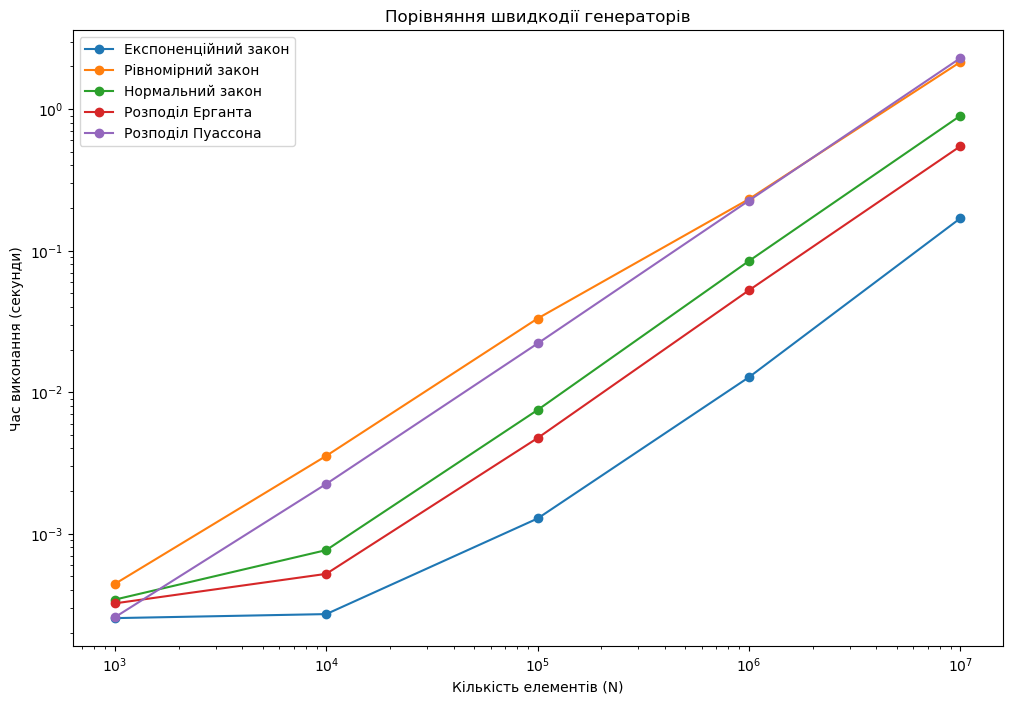

In [84]:
plt.figure(figsize=(12, 8))

for name, (sizes, times) in results.items():
    plt.plot(sizes, times, marker='o', label=name)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Кількість елементів (N)')
plt.ylabel('Час виконання (секунди)')
plt.title('Порівняння швидкодії генераторів')
plt.legend()
plt.show()

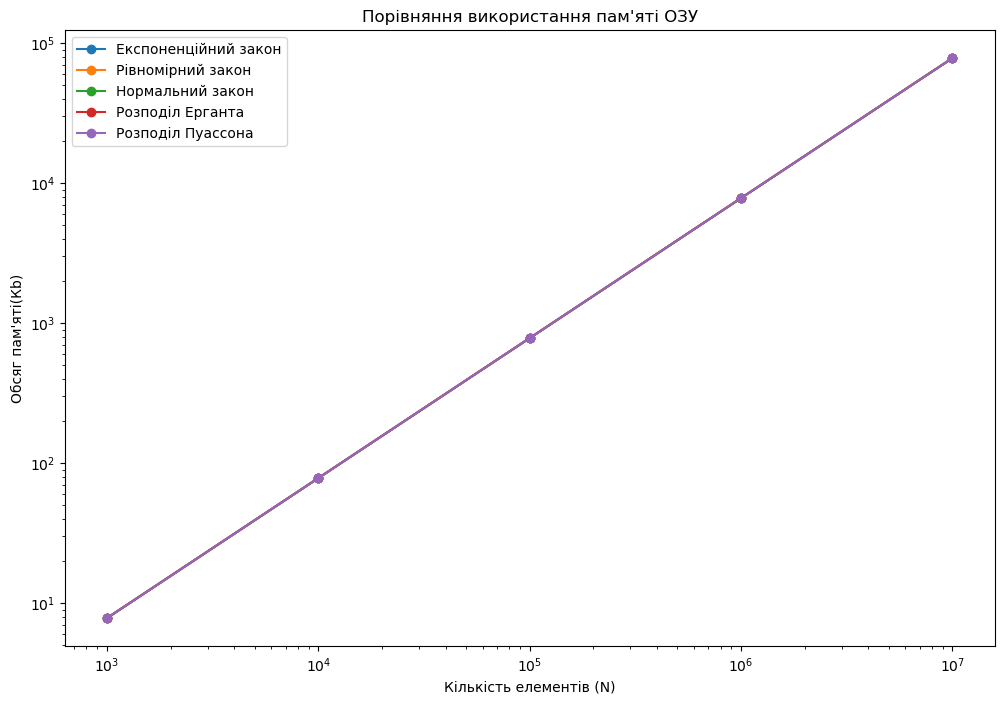

In [87]:
plt.figure(figsize=(12, 8))

for name, (sizes, times) in results.items():
    plt.plot(sizes, memory, marker='o', label=name)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Кількість елементів (N)')
plt.ylabel("Обсяг пам'яті(Кb)")
plt.title("Порівняння використання пам'яті ОЗУ")
plt.legend()
plt.show()